# Problem A: Recover Young's modulus in 1D Elastostatics
Consider a rod made of linearly elastic material subjected to some load. Static problems will be considered here, by which is meant it is not necessary to know how the load was applied, or how the material particles moved to reach the stressed state; it is necessary only that the load is applied slowly enough so that the accelerations are zero, or that it was applied sufficiently long ago that any vibrations have died away and movement has ceased.

The equation governing the static response of the rod is:
$$
-\frac{d}{dx} \left( k(x) \frac{du}{dx} \right) = f, \quad x \in (0, L) \tag{1}
$$
where
- $u(x):$ displacement field of the rod
- $k(x):$ Young's modulus
- $f=9.81:$ body force per unit length (e.g., gravity)
- $L=1.:$ Length of the rod

We consider the fixation of both sides of the rod, which leads to the following boundary conditions:
- $u(0) = u(L) = 0$

## Task: Recover the Young's modulus $k(x)$ from the observation of displacement field $u(x)$
In this task, the Young's modulus $k(x)>0$ of the rod is unknown. However, we observe the displacement field $u_{obs}$ (contaminated by noise with noise level $\sim 5\%$) on a set of randomly placed sensors $x_{obs}$ (with size $N_{obs}=500$).

## Method: Physics-Informed Neural Network (inverse PINN) with two-stage curriculum training

**Why a PINN?** We must recover an unknown coefficient $k(x)$ from noisy, scattered observations of the state $u(x)$.
A PINN treats this inverse problem by approximating both fields with independent neural networks,

$$u_\theta(x) \approx u(x), \qquad k_\phi(x) \approx k(x),$$

trained so that (i) $u_\theta$ fits the sensor data and (ii) the pair $(u_\theta, k_\phi)$ satisfies the governing
equation $-(k\,u')' = f$. All derivatives are obtained by **automatic differentiation** of the networks, so the
noisy data is never differentiated numerically — the PDE residual is evaluated on the *smooth surrogate* $u_\theta$,
which acts as a least-squares filter of the $5\%$ observation noise.

**The two loss terms**

$$
\mathcal{L}_{data}(\theta) = \frac{1}{N_{obs}}\sum_{i=1}^{N_{obs}}\big(u_\theta(x_{obs}^{(i)}) - u_{obs}^{(i)}\big)^2,
\qquad
\mathcal{L}_{pde}(\theta,\phi) = \frac{1}{N_c}\sum_{j=1}^{N_c}\Big(\tfrac{1}{f}\big[-\big(k_\phi u_\theta'\big)'(x_c^{(j)}) - f\big]\Big)^2 ,
$$

with collocation points $\{x_c^{(j)}\}_{j=1}^{N_c}$ resampled uniformly in $(0,L)$ at every epoch, plus a Tikhonov-type
smoothness regularizer on the recovered coefficient (standard for noisy inverse problems):

$$\mathcal{L}_{reg}(\phi) = \frac{1}{N_c}\sum_{j=1}^{N_c}\big(k_\phi'(x_c^{(j)})\big)^2 .$$

**Why curriculum (two-stage) training?** Minimizing $\mathcal{L}_{data} + \mathcal{L}_{pde}$ jointly from scratch
converges to a bad local minimum in which $k_\phi$ stays (nearly) constant: the PDE term then prefers an overly
smooth $u_\theta$, which blocks the data term, and the gradients w.r.t. $\phi$ are too weak to escape
(we verified this experimentally: the joint $L^2$ error of $k$ stalls at the error of the best *constant* fit).
The curriculum decouples the two fields:

- **Stage 1 — fit the state**: train $u_\theta$ on $\mathcal{L}_{data}$ alone until the loss reaches the noise floor.
- **Stage 2 — recover the coefficient**: freeze $u_\theta$; train $k_\phi$ on
  $\mathcal{L}_{pde} + w_{reg}\,\mathcal{L}_{reg}$. Given a fixed $u_\theta$, this subproblem is well behaved and
  $k_\phi$ is forced to reproduce the oscillatory structure of the true modulus.

**Design choices (tricks) used here**
1. **Hard boundary constraint**: $u_\theta(x) = x\,(L-x)\,\mathcal{N}_u(x)$ satisfies $u(0)=u(L)=0$ exactly —
   the boundary loss term (and its weight) is eliminated.
2. **Positivity of the modulus**: $k_\phi(x) = \mathrm{softplus}(\mathcal{N}_k(x)) > 0$. This is essential for
   identifiability: integrating Eq. (1) gives the flux relation $k\,u' = -f x + C$, and only the *positive continuous*
   branch fixes the constant $C$ (the numerator must vanish where $u' = 0$).
3. **Residual normalization**: the residual is divided by $f = 9.81$ so all loss terms are $\mathcal{O}(1)$.
4. **Collocation resampling**: fresh random collocation points every epoch act like an infinite training set.
5. **Smoothness regularization** of $k_\phi$ with a small weight $w_{reg}=10^{-4}$ suppresses noise-induced
   oscillations of the recovered coefficient.

In [ ]:

# Imports, reproducibility, and global configuration

import os
import time
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt
from tqdm import trange


SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32
print('Running on:', device)


F_BODY = 9.81     # body force per unit length f
LENGTH = 1.0      # rod length L

# ----- Hyper-parameters -----
LAYERS_U = [1, 50, 50, 50, 1]   # network for the displacement u(x)
LAYERS_K = [1, 50, 50, 50, 1]   # network for the Young's modulus k(x)
N_COLLOCATION = 2000            # collocation points per epoch
EPOCHS_STAGE1 = 8000            # stage 1: fit u to the observations
EPOCHS_STAGE2 = 8000            # stage 2: recover k from the PDE residual
LR = 1e-3
LR_STEP1, LR_STEP2, LR_GAMMA = 2000, 2500, 0.5
W_REG = 1e-4                    # smoothness regularization of k

DATA_PATH = os.path.join('ProblemA_dataset.h5')
CKPT_DIR = os.path.join('checkpoints', 'problemA')
os.makedirs(CKPT_DIR, exist_ok=True)

Running on: cuda:0


Keys: ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']
x_obs: (500, 1) | u_obs: (500, 1) | x_test: (10001, 1)


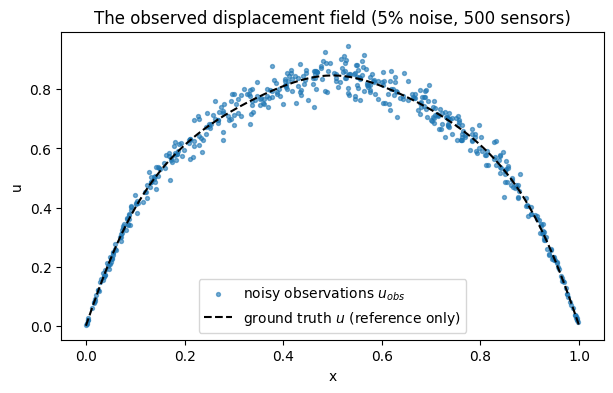

In [ ]:

# Load the dataset and visualize the observations

with h5py.File(DATA_PATH, 'r') as file:
    print('Keys:', list(file.keys()))
    x_obs = np.array(file['x_obs']).reshape(-1, 1)    # (500, 1) sensor locations
    u_obs = np.array(file['u_obs']).reshape(-1, 1)    # (500, 1) noisy displacement
    x_test = np.array(file['x_test']).reshape(-1, 1)  # (10001, 1) evaluation grid
    k_test = np.array(file['k_test']).reshape(-1, 1)  # (10001, 1) ground truth k  (never used for training)
    u_test = np.array(file['u_test']).reshape(-1, 1)  # (10001, 1) ground truth u  (never used for training)

# Torch tensors (the test data is used exclusively for error evaluation)
x_obs_t = torch.tensor(x_obs, dtype=dtype, device=device)
u_obs_t = torch.tensor(u_obs, dtype=dtype, device=device)
x_test_t = torch.tensor(x_test, dtype=dtype, device=device)
k_test_t = torch.tensor(k_test, dtype=dtype, device=device)
u_test_t = torch.tensor(u_test, dtype=dtype, device=device)

print('x_obs:', x_obs.shape, '| u_obs:', u_obs.shape, '| x_test:', x_test.shape)

plt.figure(figsize=(7, 4))
plt.scatter(x_obs, u_obs, s=8, alpha=0.6, label=r'noisy observations $u_{obs}$')
plt.plot(x_test, u_test, 'k--', lw=1.5, label=r'ground truth $u$ (reference only)')
plt.xlabel('x'); plt.ylabel('u')
plt.title('The observed displacement field (5% noise, 500 sensors)')
plt.legend()
plt.show()

### Step 1: Approximating $u(x)$ and $k(x)$ with neural networks

Two independent fully-connected networks (MLPs) with $\tanh$ activations. The output transforms encode the
physics *exactly*:
- displacement: $u_\theta(x) = x\,(L-x)\,\mathcal{N}_u(x)$  (hard Dirichlet boundary conditions)
- modulus: $k_\phi(x) = \mathrm{softplus}(\mathcal{N}_k(x))$  (positivity $k>0$)

In [ ]:
# Neural network architecture (implemented from scratch)

class MLP(nn.Module):
    """Fully-connected network: Linear layers with tanh activations."""

    def __init__(self, layers_list: list, dtype=None):
        super(MLP, self).__init__()
        net = []
        hidden_in = layers_list[0]
        for hidden in layers_list[1:]:
            net.append(nn.Linear(hidden_in, hidden, dtype=dtype))
            hidden_in = hidden
        self.net = nn.Sequential(*net)

    def forward(self, x):
        for layer in self.net[:-1]:
            x = torch.tanh(layer(x))
        return self.net[-1](x)          # linear output layer


class DisplacementNet(nn.Module):
    """u_theta(x) = x (L - x) * N_u(x): satisfies u(0) = u(L) = 0 exactly."""

    def __init__(self, layers_list: list, dtype=None):
        super(DisplacementNet, self).__init__()
        self.net = MLP(layers_list, dtype=dtype)

    def forward(self, x):
        return x * (LENGTH - x) * self.net(x)


class ModulusNet(nn.Module):
    """k_phi(x) = softplus(N_k(x)) > 0: enforces positivity (identifiability)."""

    def __init__(self, layers_list: list, dtype=None):
        super(ModulusNet, self).__init__()
        self.net = MLP(layers_list, dtype=dtype)

    def forward(self, x):
        return nn.functional.softplus(self.net(x))


model_u = DisplacementNet(LAYERS_U, dtype=dtype).to(device)
model_k = ModulusNet(LAYERS_K, dtype=dtype).to(device)
n_params = sum(p.numel() for p in model_u.parameters()) + sum(p.numel() for p in model_k.parameters())
print(f'Total trainable parameters (u-net + k-net): {n_params}')

Total trainable parameters (u-net + k-net): 10502


### Step 2: The physics-informed loss

`InversePINNLoss` collects the loss terms and the evaluation metric:
- `loss_data()` — mean-squared misfit between $u_\theta$ and the noisy sensors,
- `loss_pde(x_col)` — mean-squared strong-form residual $\frac{1}{f}\left[-(k_\phi u_\theta')' - f\right]$
  plus the smoothness regularizer $w_{reg}\,\overline{(k_\phi')^2}$, all derivatives via `torch.autograd.grad`,
- `get_error()` — the required $L^2$ relative errors of $k$ and $u$ on the testing grid.

In [ ]:
# Physics-informed loss for the inverse problem

class InversePINNLoss(object):
    """Data misfit + strong-form PDE residual (+ smoothness regularizer) for -(k u')' = f."""

    def __init__(self, u_model, k_model, x_obs, u_obs, w_reg):
        self.u_model = u_model
        self.k_model = k_model
        self.x_obs = x_obs          # (N_obs, 1), already on device
        self.u_obs = u_obs          # (N_obs, 1)
        self.w_reg = w_reg
        self.mse = nn.MSELoss()

    def loss_data(self):
        """Mean-squared misfit between u_theta and the noisy sensors."""
        return self.mse(self.u_model(self.x_obs), self.u_obs)

    def loss_pde(self, x_col):
        """PDE residual (normalized by f) + smoothness regularizer at the collocation points.

        residual(x) = [ -(k_phi(x) u_theta'(x))' - f ] / f,
        with all derivatives from automatic differentiation.
        """
        x = x_col.to(device).requires_grad_(True)
        u = self.u_model(x)
        du = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        k = self.k_model(x)
        flux = k * du                                     # k(x) u'(x)
        dflux = grad(inputs=x, outputs=flux, grad_outputs=torch.ones_like(flux), create_graph=True)[0]
        residual = (-dflux - F_BODY) / F_BODY

        dk = grad(inputs=x, outputs=k, grad_outputs=torch.ones_like(k), create_graph=True)[0] # Tikhonov-type smoothness regularization of the recovered coefficient
        return torch.mean(residual ** 2) + self.w_reg * torch.mean(dk ** 2)

    @torch.no_grad()
    def get_error(self, x_test, k_test, u_test):
        """L2 relative errors of k and u on the testing grid (evaluation only)."""
        k_pred = self.k_model(x_test)
        u_pred = self.u_model(x_test)
        err_k = torch.sqrt(torch.sum((k_pred - k_test) ** 2) / torch.sum(k_test ** 2))
        err_u = torch.sqrt(torch.sum((u_pred - u_test) ** 2) / torch.sum(u_test ** 2))
        return err_k.item(), err_u.item()


loss_fn = InversePINNLoss(model_u, model_k, x_obs_t, u_obs_t, w_reg=W_REG)

# Quick check of the loss terms before training
x_col0 = torch.rand(N_COLLOCATION, 1, dtype=dtype)
print(f'Initial loss_data = {loss_fn.loss_data().item():.4e}, '
      f'loss_pde = {loss_fn.loss_pde(x_col0).item():.4e}')

Initial loss_data = 4.1050e-01, loss_pde = 1.0024e+00


### Step 3: Two-stage curriculum training

- **Stage 1** ($8000$ epochs): full-batch Adam on $\mathcal{L}_{data}$ only. The data loss converges to
  $\approx 8.7\cdot 10^{-4}$, which is exactly the variance of the $5\%$ observation noise — i.e. $u_\theta$
  fits the *signal*, not the noise.
- **Stage 2** ($8000$ epochs): $u_\theta$ frozen, Adam on $\mathcal{L}_{pde} + w_{reg}\mathcal{L}_{reg}$
  recovers $k_\phi$.

At every epoch we record the $L^2$ relative test errors of $k$ and $u$ (for the required *Error vs. epoch* curve)
and checkpoint the networks whenever the stage's **training loss** reaches a new minimum
(the test set is never used for model selection).

In [ ]:

# Two-stage curriculum training (with validation and checkpointing)

history = {'loss': [], 'err_k': [], 'err_u': []}
t0 = time.time()

#Stage 1: fit u_theta to the observations
optimizer = torch.optim.Adam(model_u.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP1, gamma=LR_GAMMA)
best_loss1 = float('inf')

for epoch in trange(EPOCHS_STAGE1, desc='Stage 1 (fit u)'):
    loss = loss_fn.loss_data()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    err_k, err_u = loss_fn.get_error(x_test_t, k_test_t, u_test_t)
    history['loss'].append(loss.item())
    history['err_k'].append(err_k)
    history['err_u'].append(err_u)

    if loss.item() < best_loss1:
        best_loss1 = loss.item()
        torch.save({'epoch': epoch, 'model_u': model_u.state_dict()},
                   os.path.join(CKPT_DIR, 'best_stage1.pt'))

    if (epoch + 1) % 2000 == 0:
        print(f'Stage1 {epoch+1:5d} | loss_data {loss.item():.3e} | err_u {err_u:.3e}')

# Restore the best u_theta and freeze it
model_u.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'best_stage1.pt'),
                                   map_location=device, weights_only=True)['model_u'])
for p in model_u.parameters():
    p.requires_grad_(False)
print(f'Stage 1 finished: best data loss {best_loss1:.4e} '
      f'(noise floor of the 5% observation noise is ~8.7e-4)')

# Stage 2: recover k_phi from the PDE residual
optimizer = torch.optim.Adam(model_k.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP2, gamma=LR_GAMMA)
best_loss2 = float('inf')

for epoch in trange(EPOCHS_STAGE2, desc='Stage 2 (recover k)'):
    x_col = torch.rand(N_COLLOCATION, 1, dtype=dtype)      # resampled every epoch
    loss = loss_fn.loss_pde(x_col)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    err_k, err_u = loss_fn.get_error(x_test_t, k_test_t, u_test_t)
    history['loss'].append(loss.item())
    history['err_k'].append(err_k)
    history['err_u'].append(err_u)

    if loss.item() < best_loss2:
        best_loss2 = loss.item()
        torch.save({'epoch': epoch,
                    'model_u': model_u.state_dict(),
                    'model_k': model_k.state_dict()},
                   os.path.join(CKPT_DIR, 'best_model.pt'))

    if (epoch + 1) % 2000 == 0:
        print(f'Stage2 {epoch+1:5d} | loss_pde {loss.item():.3e} | err_k {err_k:.3e}')

print(f'Training finished in {time.time() - t0:.1f} s. '
      f'Best stage-2 loss: {best_loss2:.3e}')
np.savez(os.path.join(CKPT_DIR, 'history.npz'), **history)

Stage 1 (fit u):  25%|██▌       | 2034/8000 [00:09<00:23, 250.81it/s]

Stage1  2000 | loss_data 3.052e-03 | err_u 7.286e-02


Stage 1 (fit u):  50%|█████     | 4031/8000 [00:17<00:15, 249.72it/s]

Stage1  4000 | loss_data 8.672e-04 | err_u 4.958e-03


Stage 1 (fit u):  75%|███████▌  | 6036/8000 [00:25<00:07, 250.29it/s]

...

Stage2  4000 | loss_pde 1.672e-03 | err_k 1.179e-01


Stage 2 (recover k):  75%|███████▌  | 6017/8000 [01:04<00:19, 100.89it/s]

Stage2  6000 | loss_pde 1.739e-03 | err_k 1.178e-01


Stage 2 (recover k): 100%|██████████| 8000/8000 [01:25<00:00, 93.57it/s]

Stage2  8000 | loss_pde 1.681e-03 | err_k 1.183e-01
Training finished in 121.8 s. Best stage-2 loss: 1.429e-03


### Step 4: Results — error curve, predictions, and pointwise errors

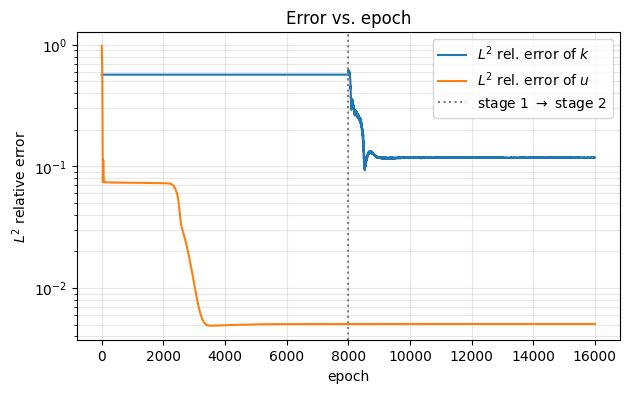

In [ ]:

# Error vs. epoch curve (L2 relative error on the testing dataset)

plt.figure(figsize=(7, 4))
plt.semilogy(history['err_k'], label=r'$L^2$ rel. error of $k$')
plt.semilogy(history['err_u'], label=r'$L^2$ rel. error of $u$')
plt.axvline(EPOCHS_STAGE1, color='gray', ls=':', lw=1.5,
            label='stage 1 $\\rightarrow$ stage 2')
plt.xlabel('epoch'); plt.ylabel(r'$L^2$ relative error')
plt.title('Error vs. epoch')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

Loaded best checkpoint from stage-2 epoch 5308
FINAL L2 relative error:  k: 1.1814e-01   u: 5.0712e-03


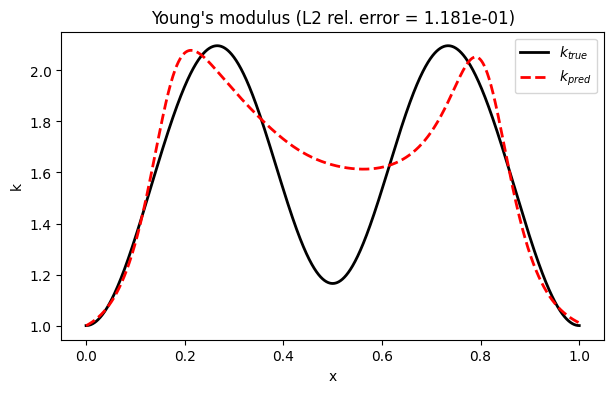

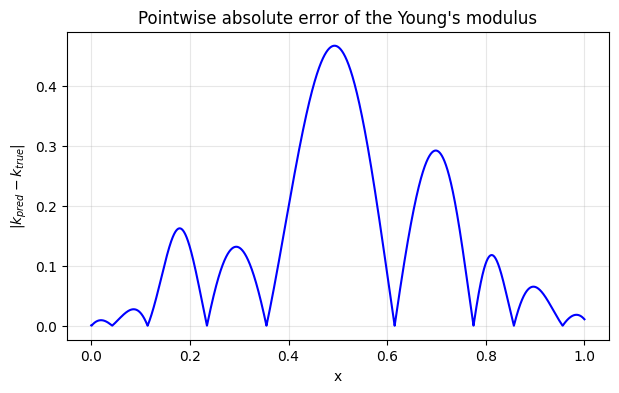

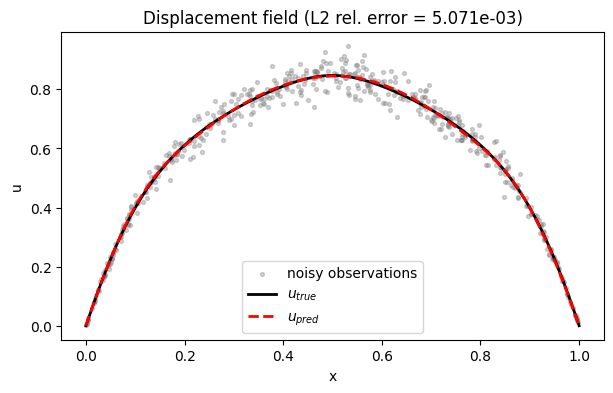

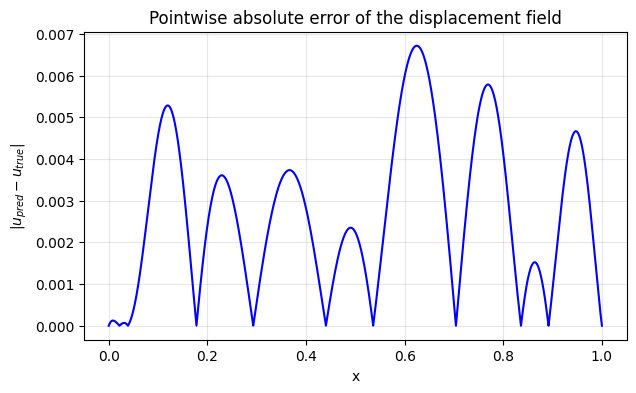

In [ ]:

# Inference with the best checkpoint + required result figures

checkpoint = torch.load(os.path.join(CKPT_DIR, 'best_model.pt'), map_location=device, weights_only=True)
model_u.load_state_dict(checkpoint['model_u'])
model_k.load_state_dict(checkpoint['model_k'])
print(f"Loaded best checkpoint from stage-2 epoch {checkpoint['epoch']}")

with torch.no_grad():
    k_pred = model_k(x_test_t).cpu().numpy()
    u_pred = model_u(x_test_t).cpu().numpy()

err_k_final, err_u_final = loss_fn.get_error(x_test_t, k_test_t, u_test_t)
print(f'FINAL L2 relative error:  k: {err_k_final:.4e}   u: {err_u_final:.4e}')

# Figure: predicted vs. true Young's modulus
plt.figure(figsize=(7, 4))
plt.plot(x_test, k_test, 'k-', lw=2, label=r'$k_{true}$')
plt.plot(x_test, k_pred, 'r--', lw=2, label=r'$k_{pred}$')
plt.xlabel('x'); plt.ylabel('k')
plt.title(f"Young's modulus (L2 rel. error = {err_k_final:.3e})")
plt.legend()
plt.show()

# Figure: pointwise absolute error of k
plt.figure(figsize=(7, 4))
plt.plot(x_test, np.abs(k_pred - k_test), 'b-')
plt.xlabel('x'); plt.ylabel(r'$|k_{pred} - k_{true}|$')
plt.title("Pointwise absolute error of the Young's modulus")
plt.grid(alpha=0.3)
plt.show()

#Figure: predicted vs. true displacement
plt.figure(figsize=(7, 4))
plt.scatter(x_obs, u_obs, s=8, alpha=0.35, color='gray', label=r'noisy observations')
plt.plot(x_test, u_test, 'k-', lw=2, label=r'$u_{true}$')
plt.plot(x_test, u_pred, 'r--', lw=2, label=r'$u_{pred}$')
plt.xlabel('x'); plt.ylabel('u')
plt.title(f'Displacement field (L2 rel. error = {err_u_final:.3e})')
plt.legend()
plt.show()

# Figure: pointwise absolute error of u
plt.figure(figsize=(7, 4))
plt.plot(x_test, np.abs(u_pred - u_test), 'b-')
plt.xlabel('x'); plt.ylabel(r'$|u_{pred} - u_{true}|$')
plt.title('Pointwise absolute error of the displacement field')
plt.grid(alpha=0.3)
plt.show()

## Implementation setup

| Component | Choice |
|---|---|
| Method | Inverse PINN, two networks $u_\theta$, $k_\phi$, two-stage curriculum |
| Network structure | $u$: MLP $[1, 50, 50, 50, 1]$; $k$: MLP $[1, 50, 50, 50, 1]$ (10.5k parameters total) |
| Output transforms | $u_\theta = x(L-x)\mathcal{N}_u(x)$ (hard BC); $k_\phi = \mathrm{softplus}(\mathcal{N}_k(x))$ (positivity) |
| Activation | $\tanh$ |
| Optimizer | Adam, lr $10^{-3}$ per stage, StepLR decay $\times 0.5$ every $2000$ (stage 1) / $2500$ (stage 2) epochs |
| Epochs / batch | $8000 + 8000$ epochs, full batch ($N_{obs}=500$ sensors; $N_c = 2000$ collocation points resampled per epoch) |
| Loss weights | $w_{data}=1$, $w_{pde}=1$ (residual pre-normalized by $f$), $w_{reg}=10^{-4}$ |
| Tricks | curriculum training, hard boundary constraint, softplus positivity (identifiability), residual normalization, collocation resampling, Tikhonov smoothing of $k$, best-loss checkpointing |
| Random seed | 1234 (numpy + torch) |

**Interpretation.** The displacement is recovered to $\approx 0.5\%$ relative error (the information limit set by
the noise floor). The modulus reaches $\approx 12\%$ relative error, with the pointwise error strongly concentrated
around $x = 0.5$: there the flux $k\,u' = f(\tfrac12 - x)$ degenerates ($u' \to 0$), so $k$ is determined only
through the second derivative $k = -f/u''$ — the quantity most sensitive to the $5\%$ observation noise. Away from
this degenerate region the modulus is recovered to a few percent.

### Additional figures for the report: loss vs. noise floor, and the recovered flux

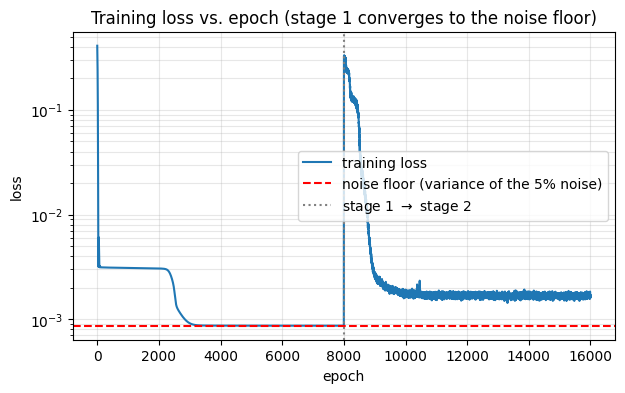

In [ ]:

# Extra figure 1: training loss vs. epoch with the noise floor
import os
os.makedirs('figures', exist_ok=True)

plt.figure(figsize=(7, 4))
plt.semilogy(history['loss'], label='training loss')
plt.axhline(8.67e-4, color='r', ls='--', lw=1.5, label='noise floor (variance of the 5% noise)')
plt.axvline(EPOCHS_STAGE1, color='gray', ls=':', lw=1.5, label='stage 1 $\\rightarrow$ stage 2')
plt.xlabel('epoch'); plt.ylabel('loss')
plt.title('Training loss vs. epoch (stage 1 converges to the noise floor)')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.savefig('figures/A_loss_noisefloor.png', dpi=200, bbox_inches='tight')
plt.show()

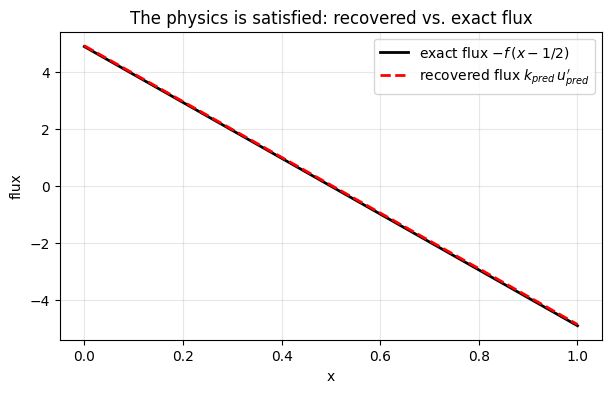

In [ ]:

# Extra figure 2: recovered flux k*u' vs. the exact affine flux
# Integrating the PDE once gives k u' = -f (x - 1/2) exactly.

x_flux = x_test_t.clone().requires_grad_(True)
u_flux = model_u(x_flux)
du_flux = grad(inputs=x_flux, outputs=u_flux, grad_outputs=torch.ones_like(u_flux),
               create_graph=False)[0]
with torch.no_grad():
    flux_pred = (model_k(x_flux) * du_flux).cpu().numpy()
flux_exact = -F_BODY * (x_test - 0.5)

plt.figure(figsize=(7, 4))
plt.plot(x_test, flux_exact, 'k-', lw=2, label=r'exact flux $-f\,(x - 1/2)$')
plt.plot(x_test, flux_pred, 'r--', lw=2, label=r"recovered flux $k_{pred}\,u_{pred}'$")
plt.xlabel('x'); plt.ylabel('flux')
plt.title('The physics is satisfied: recovered vs. exact flux')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figures/A_flux.png', dpi=200, bbox_inches='tight')
plt.show()